# 2: Exploratory Data Analysis

Goal: Profile the merged dataset and surface the descriptive patterns worth testing formally. 

**Created files:**

- `outputs/figures/eda_01_delay_minutes_distribution.png`: overall delay distribution and target balance figure.
- `outputs/figures/eda_02_delay_rate_by_season.png` through `outputs/figures/eda_10_delay_rate_by_operator.png`: temporal and operational delay-rate figures.
- `outputs/figures/eda_11_weather_hourly_distributions.png`: weather sample overview figure.
- `outputs/figures/eda_12_delay_rate_by_temperature_bin.png` through `outputs/figures/eda_15_delay_rate_by_wind_speed_bin.png`: grouped weather-condition delay-rate figures.
- `outputs/figures/eda_16_hourly_weather_vs_delay_rate.png`: continuous weather versus hourly delay-rate figure.
- `outputs/figures/eda_17_numeric_correlation_heatmap.png`, `outputs/figures/eda_18_hour_weekday_delay_heatmap.png`, and `outputs/figures/eda_19_rain_effect_by_hour_and_line.png`: multivariate interaction figures used to summarize combined patterns.


## 2.1 Setup and load the merged dataset

This section loads the merged dataset and prepares the figure output folder so the rest of the notebook can focus on analysis rather than file setup.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter

NOTEBOOK_DIR = Path.cwd().resolve()
# Support running the notebook either inside notebooks/ or from the project root.
ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
# EDA always starts from the slim merged dataset created in data_collection.ipynb.
DATASET_PATH = ROOT / "data" / "processed" / "dataset_final.csv"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# A white grid theme keeps percentage plots readable without overwhelming the report figures.
sns.set_theme(style="whitegrid", context="talk")

print(f"Project root: {ROOT}")
print(f"Dataset path: {DATASET_PATH.relative_to(ROOT)}")
print(f"Figures directory: {FIGURES_DIR.relative_to(ROOT)}")


Project root: /Users/berenaydogan/Documents/4.2/DSA210/Project/DSA210-Project
Dataset path: data/processed/dataset_final.csv
Figures directory: outputs/figures


In [2]:
# Parse the key timestamp columns up front so temporal grouping and plotting use real datetimes.
date_columns = ["service_date", "scheduled_arrival", "weather_time"]

assert DATASET_PATH.exists(), "Run data_collection.ipynb first so data/processed/dataset_final.csv exists."

df = pd.read_csv(DATASET_PATH, parse_dates=date_columns)
dataset_row_count = len(df)
dataset_column_count = len(df.columns)

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn",
]
# Preserve the intended seasonal sequence instead of letting alphabetical sorting scramble the windows.
df["season"] = pd.Categorical(
    df["season"],
    categories=season_order,
    ordered=True,
)

# These checks confirm the merge notebook produced a fully labeled, analysis table with weather matched to every row.
assert df["season"].notna().all(), "Every row should map to a season."
assert df["weather_matched"].all(), "The merged dataset should have full weather coverage."

print(f"Loaded rows: {dataset_row_count:,}")
print(f"Loaded columns: {dataset_column_count:,}")
display(df.head())


Loaded rows: 90,818
Loaded columns: 21


,service_date,season,scheduled_arrival,scheduled_arrival_date,delay_minutes,delayed,scheduled_arrival_hour,scheduled_arrival_weekday,scheduled_arrival_weekday_name,scheduled_arrival_month,...,stop_name,train_type,line_name,operator,weather_time,temperature_2m,precipitation,snowfall,wind_speed_10m,weather_matched
0,2025-01-01,Winter,2025-01-01 01:25:00,2025-01-01,-0.200000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
1,2025-01-01,Winter,2025-01-01 01:27:00,2025-01-01,1.000000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
2,2025-01-01,Winter,2025-01-01 01:34:00,2025-01-01,1.300000,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
3,2025-01-01,Winter,2025-01-01 01:35:00,2025-01-01,-0.650000,0,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True
4,2025-01-01,Winter,2025-01-01 01:52:00,2025-01-01,0.183333,1,1,2,Wednesday,1,...,Lausanne,SN,SN,SBB,2025-01-01 01:00:00,2.6,0.0,0.0,6.2,True


## 2.2 Dataset overview and integrity checks

This section checks the basic shape of the dataset, confirms the key timestamps line up as expected, and looks for missing values before I start interpreting plots.

In [3]:
scheduled_date = df["scheduled_arrival"].dt.strftime("%Y-%m-%d")
service_date = df["service_date"].dt.strftime("%Y-%m-%d")
# Count rows where scheduled arrival spills past midnight so the report can explain any mismatch in the service date.
overnight_spillover_rows = (scheduled_date != service_date).sum()

overview_df = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "unique train types",
            "stations in the Lausanne area",
            "unique lines",
            "unique operators",
            "service date start",
            "service date end",
            "scheduled-arrival start",
            "scheduled-arrival end",
            "weather coverage",
            "overnight spillover rows",
        ],
        "value": [
            dataset_row_count,
            dataset_column_count,
            df["train_type"].nunique(),
            df["stop_name"].nunique(),
            df["line_name"].nunique(),
            df["operator"].nunique(),
            df["service_date"].min().date().isoformat(),
            df["service_date"].max().date().isoformat(),
            df["scheduled_arrival"].min().isoformat(sep=" "),
            df["scheduled_arrival"].max().isoformat(sep=" "),
            f"{df['weather_matched'].mean():.2%}",
            int(overnight_spillover_rows),
        ],
    }
)

station_counts = (
    df["stop_name"]
    .value_counts()
    .rename_axis("stop_name")
    .reset_index(name="rows")
)

display(overview_df)
display(station_counts)


,metric,value
0,rows,90818
1,columns,21
2,unique train types,9
3,stations in the Lausanne area,4
4,unique lines,27
5,unique operators,2
6,service date start,2025-01-01
7,service date end,2025-10-30
8,scheduled-arrival start,2025-01-01 01:25:00
9,scheduled-arrival end,2025-10-31 01:52:00


,stop_name,rows
0,Lausanne,63942
1,Romanel-sur-Lausanne,10749
2,Lausanne-Chauderon,10749
3,Lausanne-Flon,5378


In [4]:
missing_summary = (
    df.isna()
    .sum()
    .rename("missing_rows")
    .to_frame()
    # Use assign so the percentage is computed from the grouped table without creating a separate temporary object.
    .assign(missing_pct=lambda x: x["missing_rows"] / len(df))
)
missing_summary = missing_summary[missing_summary["missing_rows"] > 0].sort_values(
    "missing_rows", ascending=False
)

day_gap = (
    df["scheduled_arrival"].dt.normalize() - df["service_date"].dt.normalize()
).dt.days

timestamp_checks = pd.DataFrame(
    {
        "check": [
            "Rows missing critical timestamps",
            "Rows missing weather timestamp",
            "Rows missing any hourly weather variable",
            "Rows with weather_matched = False",
            "Rows with scheduled arrival on service date",
            "Rows with scheduled arrival one day after service date",
            "Rows with any other service date gap",
        ],
        "value": [
            int(df[["service_date", "scheduled_arrival", "delay_minutes", "delayed"]].isna().any(axis=1).sum()),
            int(df["weather_time"].isna().sum()),
            # Run this check across the four weather columns to confirm the merge did not leave partial hourly data behind.
            int(df[["temperature_2m", "precipitation", "snowfall", "wind_speed_10m"]].isna().any(axis=1).sum()),
            int((~df["weather_matched"]).sum()),
            int((day_gap == 0).sum()),
            int((day_gap == 1).sum()),
            int((~day_gap.isin([0, 1])).sum()),
        ],
    }
)

if missing_summary.empty:
    print(
        "The slim analysis dataset has no missing values in the retained analysis columns. "
        "The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps."
    )
else:
    print(
        "The remaining missing values are limited to retained analysis fields that still need interpretation. "
        "The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps."
    )
display(missing_summary)
display(timestamp_checks)


The slim analysis dataset has no missing values in the retained analysis columns. The overnight spillover rows reflect trains scheduled shortly after midnight, not corrupted timestamps.


,missing_rows,missing_pct


,check,value
0,Rows missing critical timestamps,0
1,Rows missing weather timestamp,0
2,Rows missing any hourly weather variable,0
3,Rows with weather_matched = False,0
4,Rows with scheduled arrival on service date,87620
5,Rows with scheduled arrival one day after serv...,3198
6,Rows with any other service date gap,0


## 2.3 Delay target balance and delay distribution

This section summarizes how common delayed arrivals are and shows how `delay_minutes` is distributed.

**Files produced in next step:** `outputs/figures/eda_01_delay_minutes_distribution.png`

In [5]:
class_balance = (
    df["delayed"]
    # Sort the binary labels so 0/1 always display in the natural order of on time versus late.
    .value_counts()
    .sort_index()
    .rename_axis("delayed")
    .reset_index(name="rows")
)
class_balance["label"] = class_balance["delayed"].map({0: "On time or early", 1: "Late"})
class_balance["share"] = class_balance["rows"] / len(df)

season_summary = (
    df.groupby("season", observed=True)
    .agg(
        rows=("delayed", "size"),
        late_arrivals=("delayed", "sum"),
        delay_rate=("delayed", "mean"),
        mean_delay_minutes=("delay_minutes", "mean"),
        median_delay_minutes=("delay_minutes", "median"),
    )
    .reset_index()
)

overall_delay_summary = pd.DataFrame(
    {
        "metric": ["overall delay rate", "late arrivals", "on-time-or-early arrivals"],
        "value": [
            df["delayed"].mean(),
            int(df["delayed"].sum()),
            int((1 - df["delayed"]).sum()),
        ],
    }
)

display(overall_delay_summary)
display(class_balance[["delayed", "label", "rows", "share"]])
display(season_summary)


,metric,value
0,overall delay rate,0.474113
1,late arrivals,43058.000000
2,on-time-or-early arrivals,47760.000000


,delayed,label,rows,share
0,0,On time or early,47760,0.525887
1,1,Late,43058,0.474113


,season,rows,late_arrivals,delay_rate,mean_delay_minutes,median_delay_minutes
0,Winter,25052,11764,0.469583,0.285442,-0.066667
1,Spring,24769,11610,0.468731,0.322391,-0.083333
2,Summer,16001,7365,0.460284,0.439741,-0.100000
3,Autumn,24996,12319,0.492839,0.430520,-0.016667


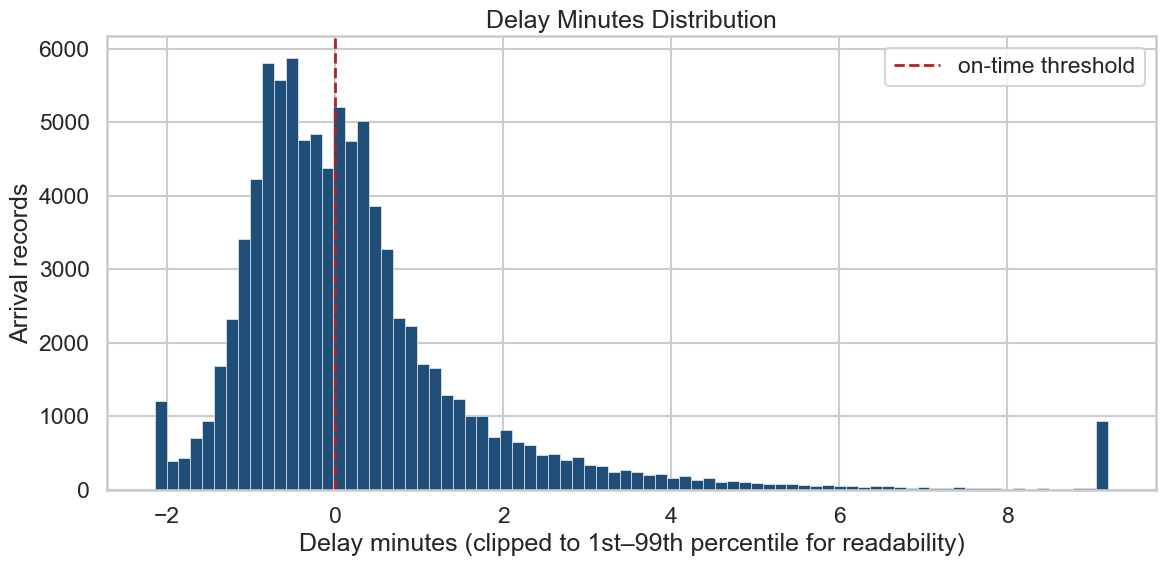

Saved figure to outputs/figures/eda_01_delay_minutes_distribution.png


,quantile,delay_minutes
0,0.00,-147.350000
1,0.01,-2.150000
2,0.05,-1.350000
3,0.25,-0.683333
4,0.50,-0.066667
5,0.75,0.666667
6,0.95,3.166667
7,0.99,9.200000
8,1.00,119.933333


In [6]:
# Use extreme, tail, quartile, and median cut points to summarize both punctual arrivals and large delay outliers.
delay_quantiles = df["delay_minutes"].quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0])
delay_quantiles_df = delay_quantiles.rename_axis("quantile").reset_index(name="delay_minutes")

lower_clip = delay_quantiles.loc[0.01]
upper_clip = delay_quantiles.loc[0.99]
plot_values = df["delay_minutes"].clip(lower=lower_clip, upper=upper_clip)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(plot_values, bins=80, color="#1f4e79", edgecolor="white", linewidth=0.4)
ax.axvline(0, color="#b22222", linestyle="--", linewidth=2, label="on-time threshold")
ax.set_title("Delay Minutes Distribution")
ax.set_xlabel("Delay minutes (clipped to 1st–99th percentile for readability)")
ax.set_ylabel("Arrival records")
ax.legend()
fig.tight_layout()

delay_plot_path = FIGURES_DIR / "eda_01_delay_minutes_distribution.png"
fig.savefig(delay_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {delay_plot_path.relative_to(ROOT)}")
display(delay_quantiles_df)


## 2.4 Plotting helpers

This section defines the helper functions that keep the grouped delay plots consistent.

Implementation detail: safe to skim on a first read.

In [7]:
# Use explicit weekday ordering so seaborn/bar plots do not fall back to alphabetical day names.
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]
weekend_label_map = {False: "Weekday", True: "Weekend"}


def build_delay_summary(
    data: pd.DataFrame,
    column: str,
    order: list | None = None,
    label_map: dict | None = None,
    sort_desc: bool = False,
) -> pd.DataFrame:
    summary = (
        data.groupby(column, observed=False)
        .agg(
            rows=("delayed", "size"),
            delay_rate=("delayed", "mean"),
            mean_delay_minutes=("delay_minutes", "mean"),
        )
        .reset_index()
    )
    summary = summary[summary["rows"] > 0].copy()
    summary["category"] = summary[column].map(label_map) if label_map else summary[column]

    if order is not None:
        ordered_labels = [label_map.get(item, item) if label_map else item for item in order]
        summary["category"] = pd.Categorical(
            summary["category"],
            categories=ordered_labels,
            ordered=True,
        )
        summary = summary.sort_values("category")
    elif sort_desc:
        summary = summary.sort_values(["delay_rate", "rows"], ascending=[False, False])

    return summary.reset_index(drop=True)


def save_delay_rate_plot(
    summary: pd.DataFrame,
    title: str,
    filename: str,
    x_label: str,
    rotate: int = 0,
    figsize: tuple[float, float] = (12, 6),
    annotate_counts: bool = False,
) -> Path:
    fig, ax = plt.subplots(figsize=figsize)
    category_labels = summary["category"].astype(str).tolist()
    positions = list(range(len(summary)))
    bars = ax.bar(positions, summary["delay_rate"], color="#1f4e79", width=0.8)
    ax.set_xticks(positions)
    ax.set_xticklabels(category_labels)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Delay rate")
    ax.set_ylim(0, max(0.05, summary["delay_rate"].max() * 1.15))
    if rotate:
        plt.setp(ax.get_xticklabels(), rotation=rotate, ha="right")
    if annotate_counts and len(summary) <= 10:
        for patch, row in zip(bars, summary.itertuples(index=False)):
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                patch.get_height(),
                f"n={row.rows:,}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    fig.tight_layout()
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    return output_path


## 2.5 Temporal and operational delay rate views

This section looks at how delays are distributed according to temporal and operational features:
- Season 
- Hour
- Day of the week
- Month
- Whether the day is a weekend
- Station
- Train type
- Line
- Operator

**Files produced in next step:** `outputs/figures/eda_02_delay_rate_by_season.png` through `outputs/figures/eda_10_delay_rate_by_operator.png`

In [8]:
# Drive the repeated bar plots from one spec list so every temporal/operational view uses the same summary and save logic.
rate_plot_specs = [
    {
        "column": "season",
        "title": "Delay Rate by Season",
        "filename": "eda_02_delay_rate_by_season.png",
        "x_label": "Season",
        "order": season_order,
        "label_map": None,
        # rotate controls readability of the horizontal axis labels, while figsize makes dense categories easier to read in the exported report figure.
        "rotate": 15,
        "figsize": (12, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_hour",
        "title": "Delay Rate by Scheduled Arrival Hour",
        "filename": "eda_03_delay_rate_by_hour.png",
        "x_label": "Scheduled arrival hour",
        "order": list(range(24)),
        "label_map": None,
        "rotate": 0,
        "figsize": (14, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_weekday_name",
        "title": "Delay Rate by Day of Week",
        "filename": "eda_04_delay_rate_by_weekday.png",
        "x_label": "Day of week",
        "order": weekday_order,
        "label_map": None,
        "rotate": 20,
        "figsize": (12, 6),
        "sort_desc": False,
    },
    {
        "column": "scheduled_arrival_month",
        "title": "Delay Rate by Calendar Month",
        "filename": "eda_05_delay_rate_by_month.png",
        "x_label": "Calendar month",
        "order": sorted(df["scheduled_arrival_month"].unique()),
        "label_map": None,
        "rotate": 0,
        "figsize": (10, 6),
        "sort_desc": False,
    },
    {
        "column": "is_weekend",
        "title": "Delay Rate by Weekend Indicator",
        "filename": "eda_06_delay_rate_by_weekend_indicator.png",
        "x_label": "Weekend indicator",
        "order": [False, True],
        "label_map": weekend_label_map,
        "rotate": 0,
        "figsize": (8, 6),
        "sort_desc": False,
    },
    {
        "column": "stop_name",
        "title": "Delay Rate by Station",
        "filename": "eda_07_delay_rate_by_station.png",
        "x_label": "Station",
        "order": None,
        "label_map": None,
        "rotate": 20,
        "figsize": (12, 6),
        "sort_desc": True,
    },
    {
        "column": "train_type",
        "title": "Delay Rate by Train Type",
        "filename": "eda_08_delay_rate_by_train_type.png",
        "x_label": "Train type",
        "order": None,
        "label_map": None,
        "rotate": 0,
        "figsize": (12, 6),
        "sort_desc": True,
    },
    {
        "column": "line_name",
        "title": "Delay Rate by Line Name",
        "filename": "eda_09_delay_rate_by_line_name.png",
        "x_label": "Line name",
        "order": None,
        "label_map": None,
        "rotate": 65,
        "figsize": (16, 8),
        "sort_desc": True,
    },
    {
        "column": "operator",
        "title": "Delay Rate by Operator",
        "filename": "eda_10_delay_rate_by_operator.png",
        "x_label": "Operator",
        "order": None,
        "label_map": None,
        "rotate": 0,
        "figsize": (8, 6),
        "sort_desc": True,
    },
]


,season,rows,delay_rate,mean_delay_minutes,category
0,Winter,25052,0.469583,0.285442,Winter
1,Spring,24769,0.468731,0.322391,Spring
2,Summer,16001,0.460284,0.439741,Summer
3,Autumn,24996,0.492839,0.430520,Autumn


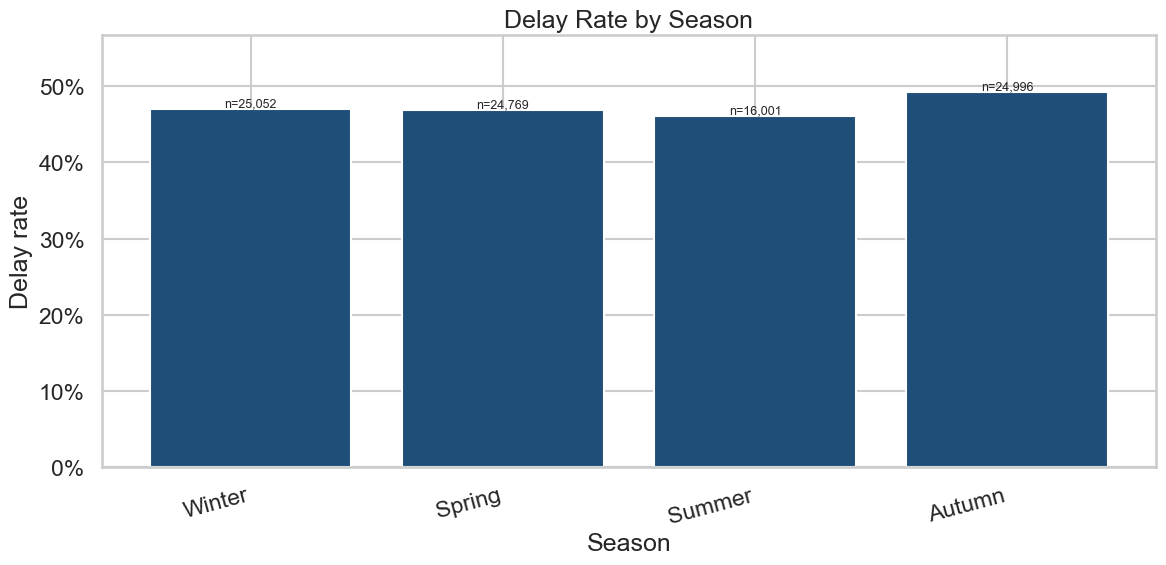

,scheduled_arrival_hour,rows,delay_rate,mean_delay_minutes,category
0,0,2271,0.623074,1.228739,0
1,1,933,0.650589,1.453162,1
2,2,282,0.539007,1.038830,2
3,3,142,0.795775,0.624883,3
4,4,213,0.661972,0.962050,4
5,5,2206,0.611967,0.615481,5
6,6,4749,0.542851,0.494746,6
7,7,4998,0.566226,0.667053,7
8,8,5070,0.524063,0.467143,8
9,9,4881,0.440484,0.133176,9


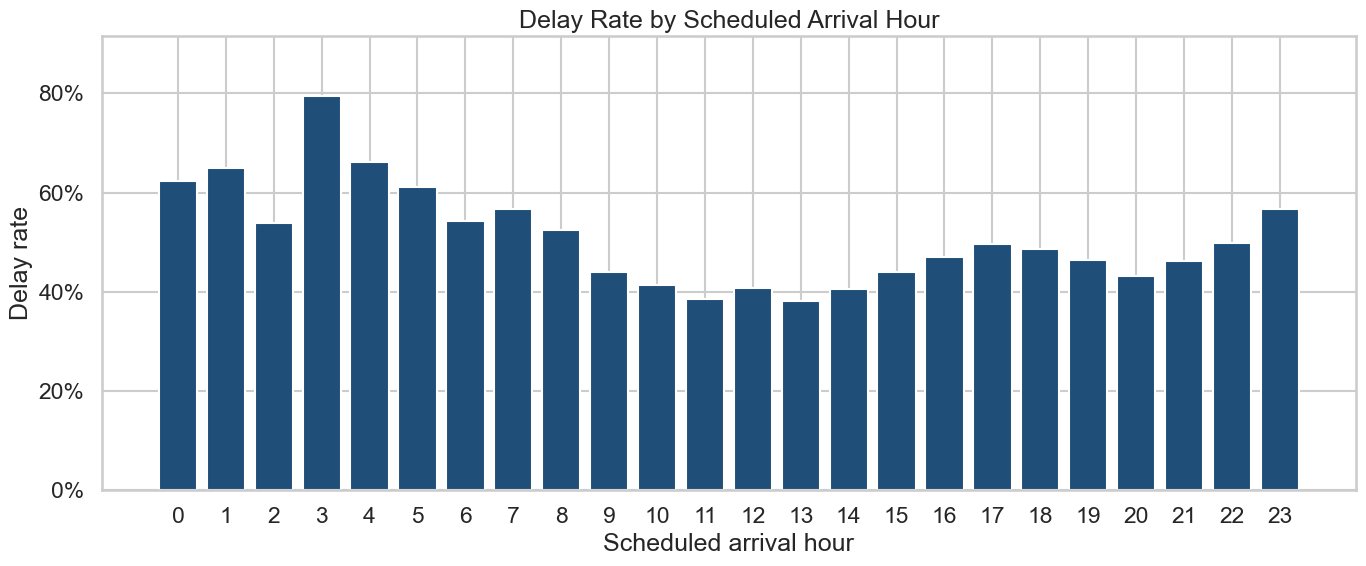

,scheduled_arrival_weekday_name,rows,delay_rate,mean_delay_minutes,category
0,Monday,12275,0.507862,0.485226,Monday
1,Tuesday,13737,0.485841,0.389566,Tuesday
2,Wednesday,15280,0.485471,0.457357,Wednesday
3,Thursday,13973,0.507980,0.482333,Thursday
4,Friday,12482,0.477167,0.362487,Friday
5,Saturday,12464,0.425144,0.170063,Saturday
6,Sunday,10607,0.412841,0.118211,Sunday


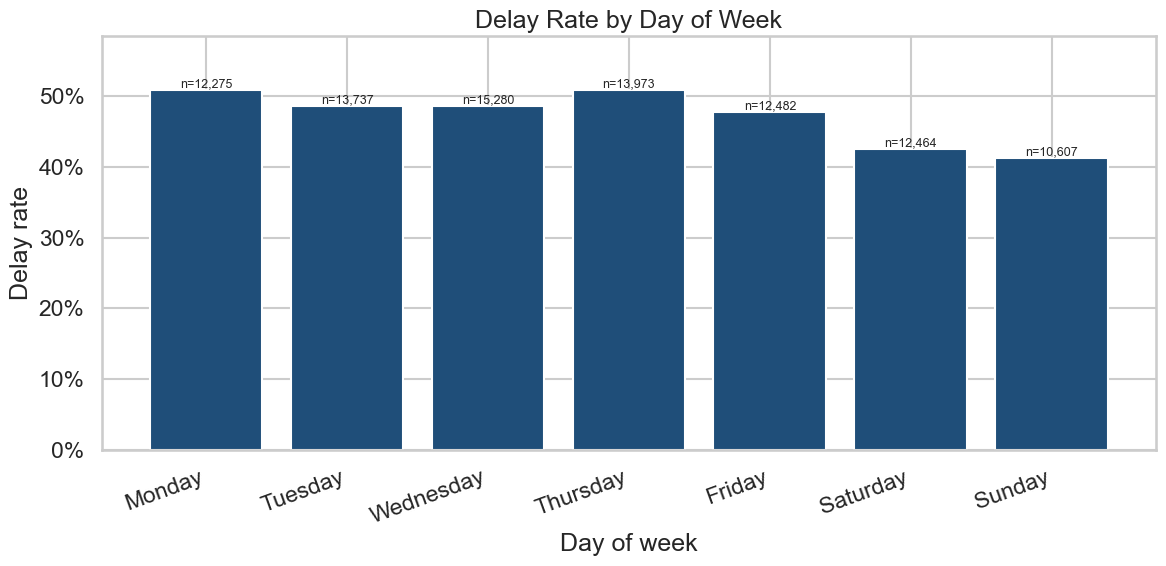

,scheduled_arrival_month,rows,delay_rate,mean_delay_minutes,category
0,1,25052,0.469583,0.285442,1
1,4,24744,0.468679,0.322471,4
2,5,25,0.520000,0.243333,5
3,7,16001,0.460284,0.439741,7
4,10,24996,0.492839,0.430520,10


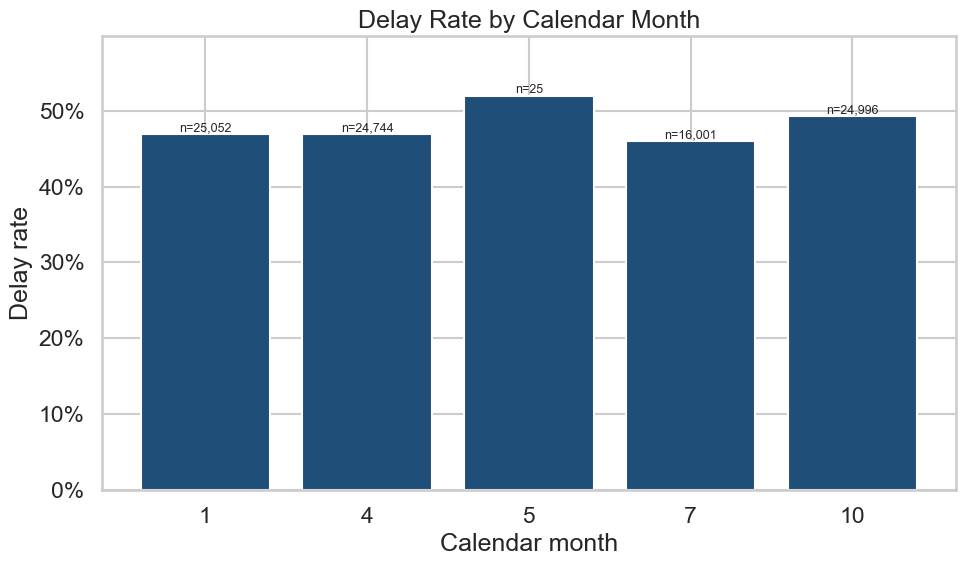

,is_weekend,rows,delay_rate,mean_delay_minutes,category
0,False,67747,0.492716,0.436333,Weekday
1,True,23071,0.419488,0.146224,Weekend


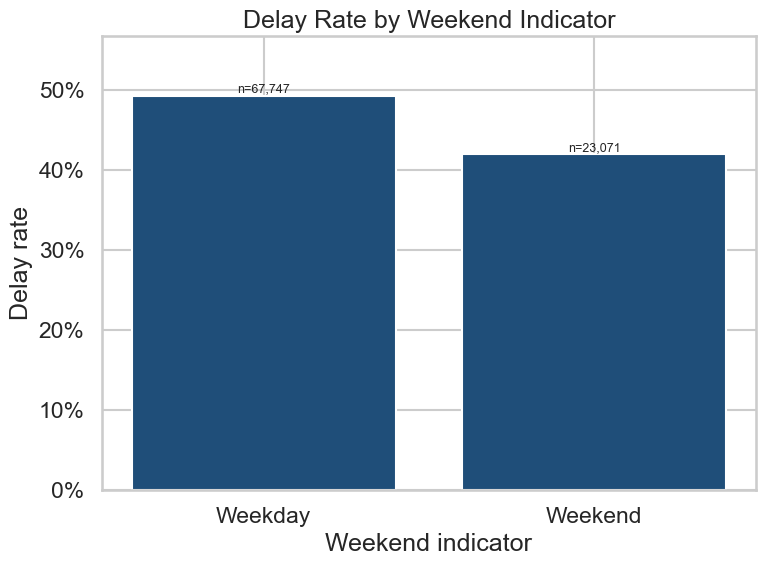

,stop_name,rows,delay_rate,mean_delay_minutes,category
0,Lausanne-Chauderon,10749,0.558005,0.160502,Lausanne-Chauderon
1,Romanel-sur-Lausanne,10749,0.540888,0.311178,Romanel-sur-Lausanne
2,Lausanne,63942,0.475493,0.471051,Lausanne
3,Lausanne-Flon,5378,0.156564,-0.419530,Lausanne-Flon


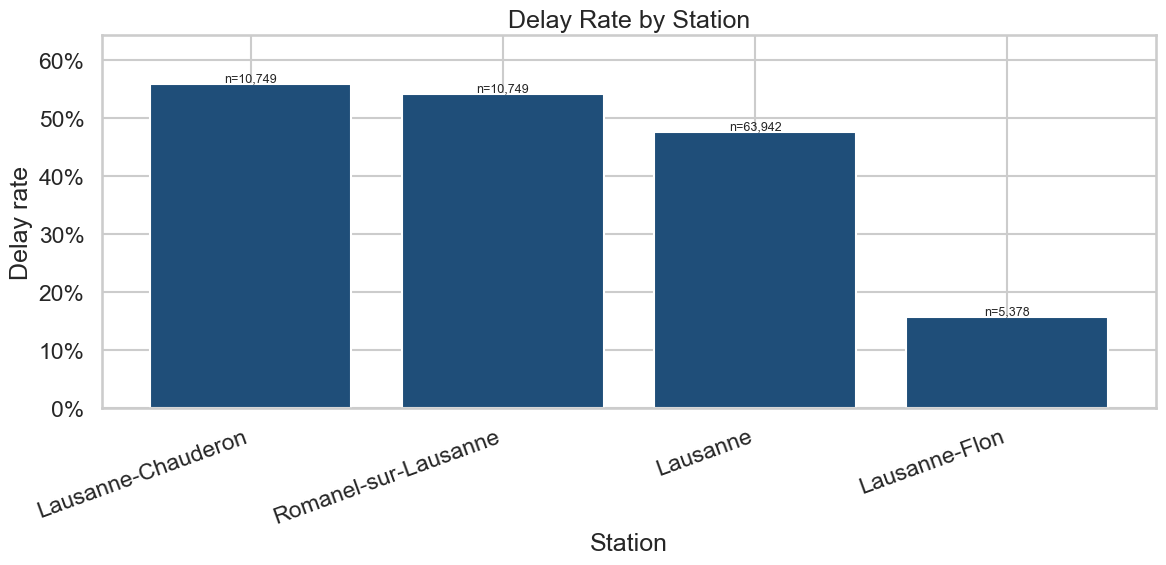

,train_type,rows,delay_rate,mean_delay_minutes,category
0,EXT,134,0.686567,3.251368,EXT
1,S,4755,0.635962,0.881013,S
2,RE,8865,0.632487,0.834247,RE
3,SN,395,0.526582,0.447637,SN
4,TGV,610,0.508197,4.870055,TGV
5,R,54082,0.492437,0.304202,R
6,EC,715,0.488112,1.474266,EC
7,IC,8381,0.362487,0.177686,IC
8,IR,12881,0.294853,-0.095444,IR


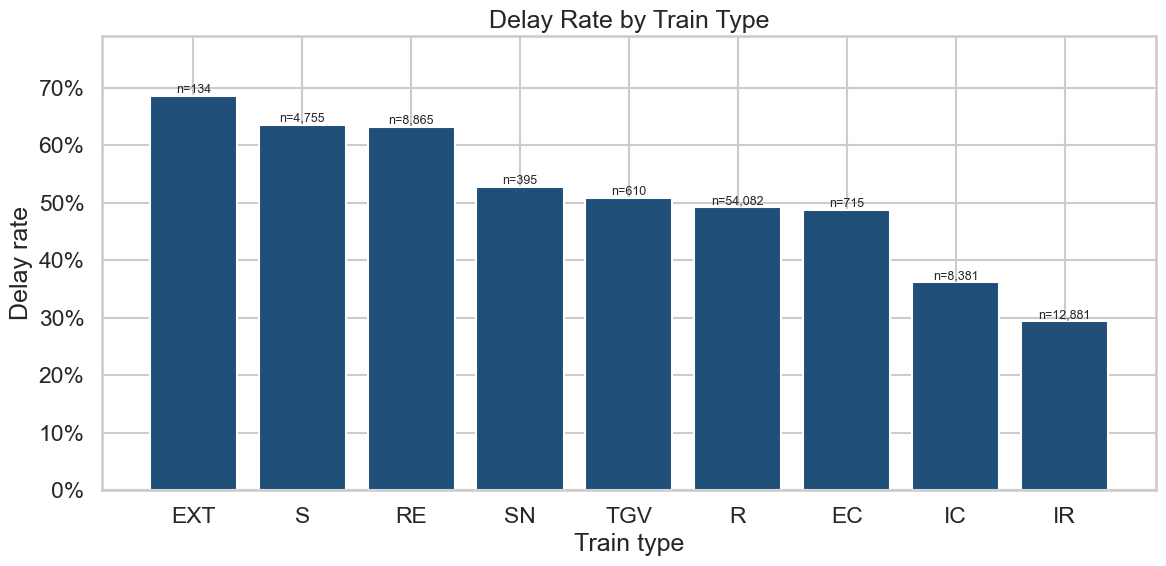

,line_name,rows,delay_rate,mean_delay_minutes,category
0,R,3,1.000000,2.061111,R
1,EXT15,1,1.000000,26.666667,EXT15
2,EXT33,1,1.000000,7.950000,EXT33
3,EXT,131,0.687023,3.070483,EXT
4,S40,2266,0.675199,0.888732,S40
5,R2,4495,0.643382,0.529140,R2
6,RE33,8709,0.635090,0.847503,RE33
7,S41,2489,0.600241,0.873986,S41
8,R8,3908,0.595957,0.746981,R8
9,R9,4728,0.565567,0.604963,R9


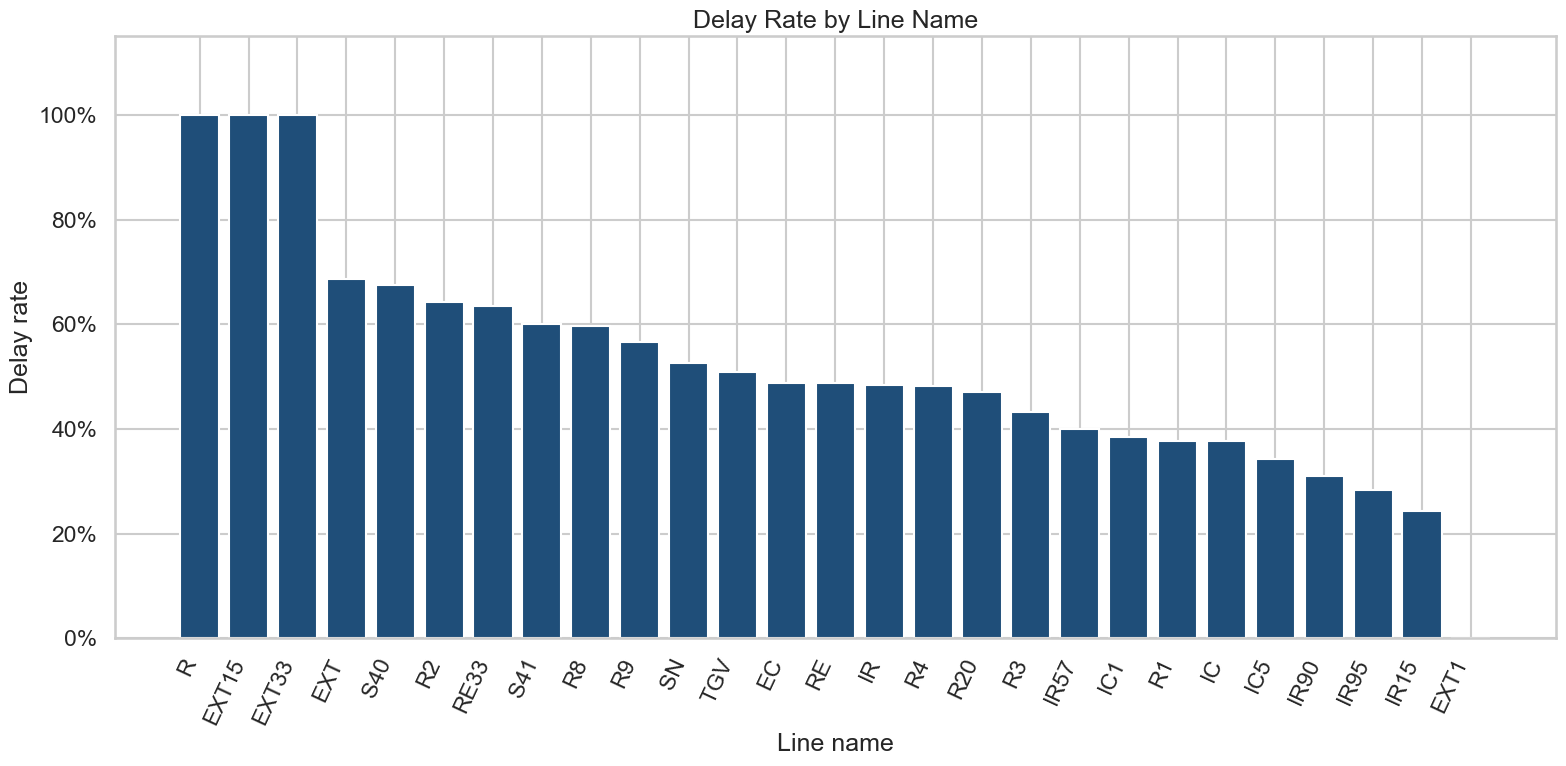

,operator,rows,delay_rate,mean_delay_minutes,category
0,SBB,63942,0.475493,0.471051,SBB
1,LEB,26876,0.470829,0.104697,LEB


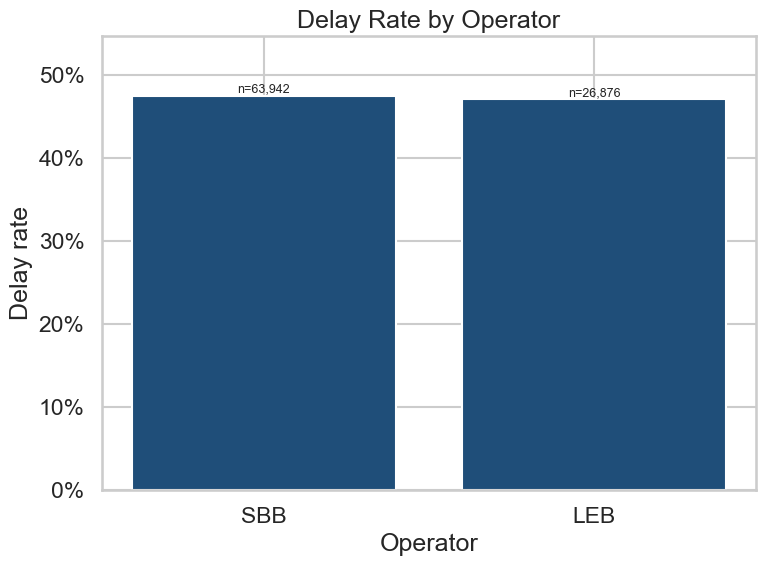

Saved temporal/operational figures:
- outputs/figures/eda_02_delay_rate_by_season.png
- outputs/figures/eda_03_delay_rate_by_hour.png
- outputs/figures/eda_04_delay_rate_by_weekday.png
- outputs/figures/eda_05_delay_rate_by_month.png
- outputs/figures/eda_06_delay_rate_by_weekend_indicator.png
- outputs/figures/eda_07_delay_rate_by_station.png
- outputs/figures/eda_08_delay_rate_by_train_type.png
- outputs/figures/eda_09_delay_rate_by_line_name.png
- outputs/figures/eda_10_delay_rate_by_operator.png


In [9]:
temporal_operational_summaries = {}
saved_rate_plots = []

for spec in rate_plot_specs:
    summary = build_delay_summary(
        df,
        column=spec["column"],
        order=spec["order"],
        label_map=spec["label_map"],
        sort_desc=spec["sort_desc"],
    )
    temporal_operational_summaries[spec["column"]] = summary
    display(summary)
    saved_rate_plots.append(
        save_delay_rate_plot(
            summary,
            title=spec["title"],
            filename=spec["filename"],
            x_label=spec["x_label"],
            rotate=spec["rotate"],
            figsize=spec["figsize"],
            annotate_counts=True,
        )
    )

print("Saved temporal/operational figures:")
for path in saved_rate_plots:
    print(f"- {path.relative_to(ROOT)}")


## 2.6 Hourly weather sample overview and distributions

This section steps back from delays for a moment and describes the weather sample itself.

**Files produced in next step:** `outputs/figures/eda_11_weather_hourly_distributions.png`

In [10]:
weather_hourly = (
    # Aggregate to hourly weather granularity because temperature, rain, snow, and wind are shared by all arrivals in that hour.
    df.groupby("weather_time", observed=False)
    .agg(
        arrival_records=("delayed", "size"),
        delay_rate=("delayed", "mean"),
        mean_delay_minutes=("delay_minutes", "mean"),
        temperature_2m=("temperature_2m", "first"),
        precipitation=("precipitation", "first"),
        snowfall=("snowfall", "first"),
        wind_speed_10m=("wind_speed_10m", "first"),
    )
    .reset_index()
    .sort_values("weather_time")
)

weather_distribution_summary = (
    weather_hourly[["temperature_2m", "precipitation", "snowfall", "wind_speed_10m"]]
    .describe()
    .T.reset_index()
    .rename(columns={"index": "weather_variable"})
)

display(weather_distribution_summary)
print(f"Hourly weather observations with at least one matched arrival: {len(weather_hourly):,}")
print(f"Rainy hourly observations: {(weather_hourly['precipitation'] > 0).sum():,}")
print(f"Snowy hourly observations: {(weather_hourly['snowfall'] > 0).sum():,}")


,weather_variable,count,mean,std,min,25%,50%,75%,max
0,temperature_2m,2743.0,11.103463,7.263687,-5.1,6.3,10.6,15.9,32.80
1,precipitation,2743.0,0.179657,0.557073,0.0,0.0,0.0,0.0,7.40
2,snowfall,2743.0,0.001225,0.018579,0.0,0.0,0.0,0.0,0.49
3,wind_speed_10m,2743.0,11.084470,7.109768,0.2,5.7,9.8,14.8,40.00


Hourly weather observations with at least one matched arrival: 2,743
Rainy hourly observations: 586
Snowy hourly observations: 18


In [11]:
weather_distribution_specs = [
    {
        "column": "temperature_2m",
        "title": "Temperature Distribution Across Matched Hours",
        "xlabel": "Temperature (C)",
        "bins": 30,
        "color": "#1f4e79",
    },
    {
        "column": "precipitation",
        "title": "Precipitation Distribution Across Matched Hours",
        "xlabel": "Precipitation in prior hour (mm)",
        "bins": 30,
        "color": "#2e8b57",
    },
    {
        "column": "snowfall",
        "title": "Snowfall Distribution Across Matched Hours",
        "xlabel": "Snowfall in prior hour (cm)",
        "bins": 30,
        "color": "#708090",
    },
    {
        "column": "wind_speed_10m",
        "title": "Wind-Speed Distribution Across Matched Hours",
        "xlabel": "Wind speed at 10m (km/h)",
        "bins": 30,
        "color": "#c26d2c",
    },
]


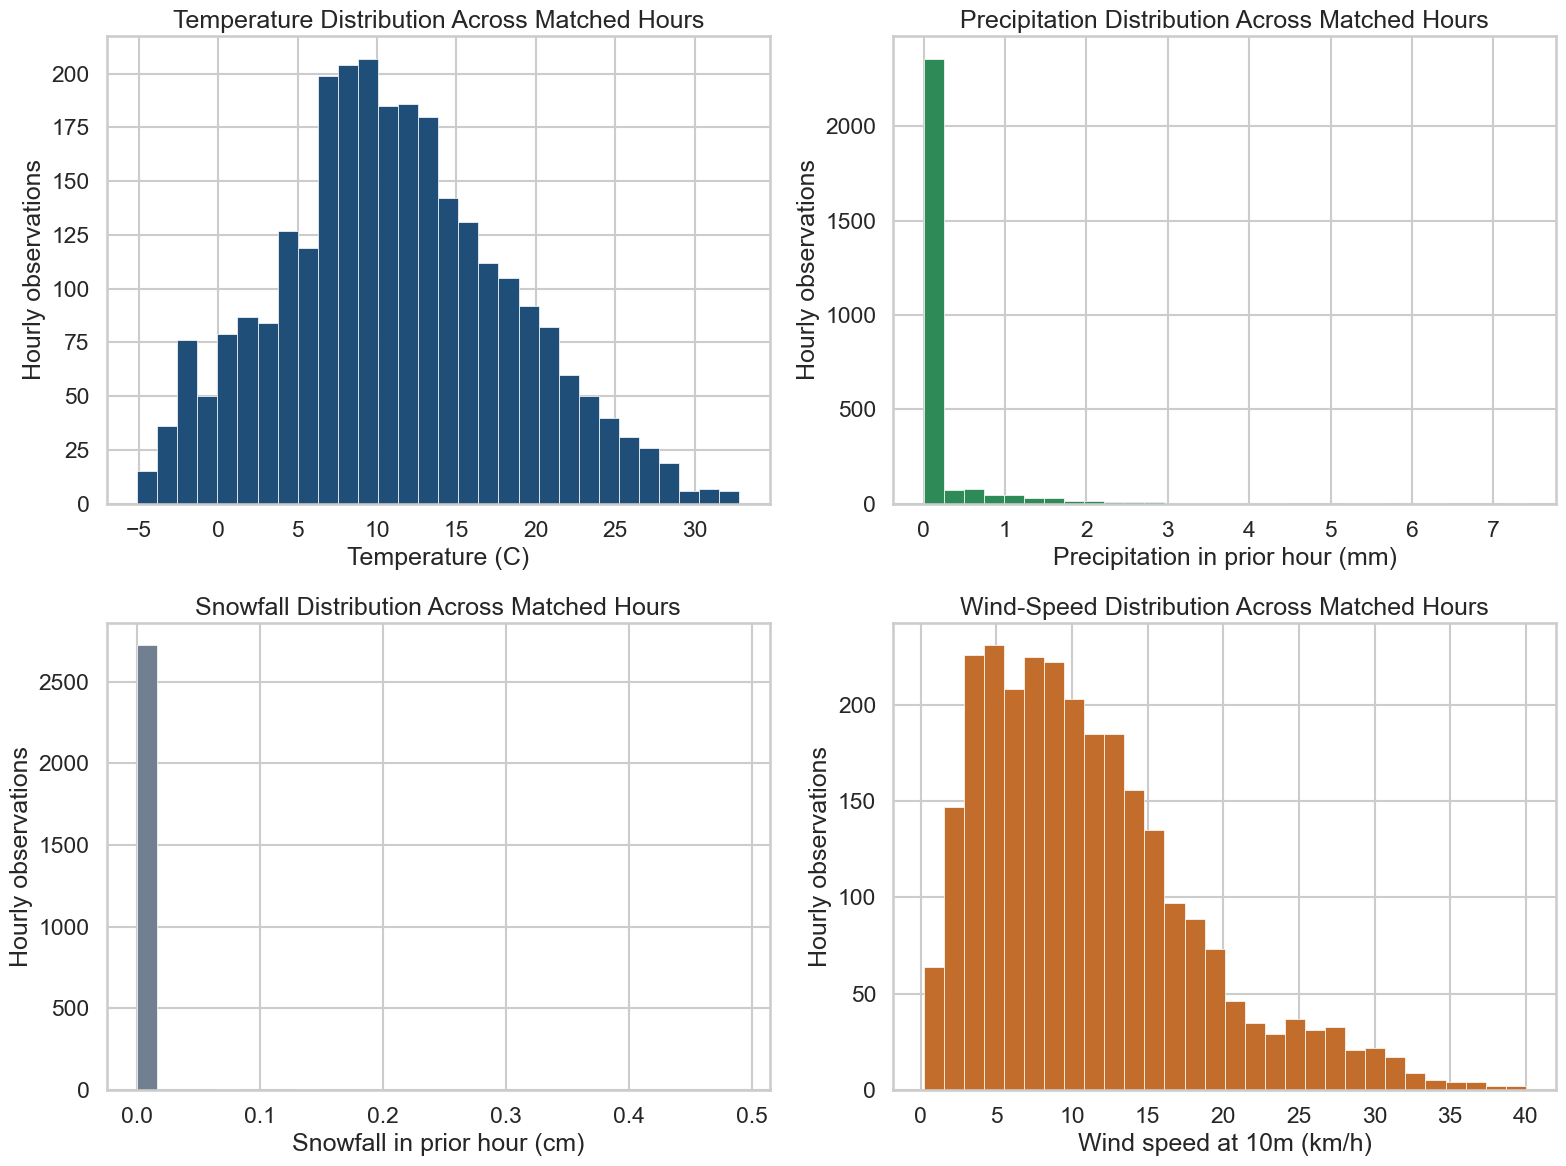

Saved figure to outputs/figures/eda_11_weather_hourly_distributions.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, spec in zip(axes.flat, weather_distribution_specs):
    ax.hist(
        weather_hourly[spec["column"]],
        bins=spec["bins"],
        color=spec["color"],
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_title(spec["title"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel("Hourly observations")

fig.tight_layout()
weather_distribution_path = FIGURES_DIR / "eda_11_weather_hourly_distributions.png"
fig.savefig(weather_distribution_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {weather_distribution_path.relative_to(ROOT)}")


## 2.7 Weather condition delay rate views

This section looks at how delays are distributed according to hourly weather features:
- Temperature
- Precipitation
- Snow
- Wind speed

For this purpose, the weather features are discretized.

**Files produced in next step:** `outputs/figures/eda_12_delay_rate_by_temperature_bin.png` through `outputs/figures/eda_15_delay_rate_by_wind_speed_bin.png`

In [13]:
weather_delay_df = df.copy()

# These bins turn continuous weather readings into interpretable report categories for grouped delay rate plots.
temperature_bin_order = [
    "<= 0 C",
    "0 to 5 C",
    "5 to 10 C",
    "10 to 15 C",
    "15 to 20 C",
    "20 to 25 C",
    "> 25 C",
]
wind_bin_order = [
    "0 to 5 km/h",
    "5 to 10 km/h",
    "10 to 15 km/h",
    "15 to 20 km/h",
    "20 to 25 km/h",
    "> 25 km/h",
]

weather_delay_df["temperature_bin"] = pd.cut(
    weather_delay_df["temperature_2m"],
    # Use coarse 5-degree bands so each temperature bin keeps enough rows for stable delay rate comparisons.
    bins=[-float("inf"), 0, 5, 10, 15, 20, 25, float("inf")],
    labels=temperature_bin_order,
    include_lowest=True,
)
weather_delay_df["wind_speed_bin"] = pd.cut(
    weather_delay_df["wind_speed_10m"],
    # Use simple 5 km/h steps so the wind plot stays readable and comparable to the temperature bins.
    bins=[0, 5, 10, 15, 20, 25, float("inf")],
    labels=wind_bin_order,
    include_lowest=True,
)
weather_delay_df["precipitation_condition"] = pd.Categorical(
    weather_delay_df["precipitation"].gt(0).map({False: "Dry hour", True: "Rainy hour"}),
    categories=["Dry hour", "Rainy hour"],
    ordered=True,
)
weather_delay_df["snowfall_condition"] = pd.Categorical(
    weather_delay_df["snowfall"].gt(0).map({False: "No snow", True: "Snowy hour"}),
    categories=["No snow", "Snowy hour"],
    ordered=True,
)


In [14]:
weather_delay_specs = [
    {
        "column": "temperature_bin",
        "title": "Delay Rate by Temperature Bin",
        "filename": "eda_12_delay_rate_by_temperature_bin.png",
        "x_label": "Temperature bin",
        "order": temperature_bin_order,
        "rotate": 20,
        "figsize": (13, 6),
    },
    {
        "column": "precipitation_condition",
        "title": "Delay Rate on Dry vs Rainy Hours",
        "filename": "eda_13_delay_rate_dry_vs_rainy.png",
        "x_label": "Precipitation condition",
        "order": ["Dry hour", "Rainy hour"],
        "rotate": 0,
        "figsize": (8, 6),
    },
    {
        "column": "snowfall_condition",
        "title": "Delay Rate on Snow vs No-Snow Hours",
        "filename": "eda_14_delay_rate_snow_vs_no_snow.png",
        "x_label": "Snowfall condition",
        "order": ["No snow", "Snowy hour"],
        "rotate": 0,
        "figsize": (8, 6),
    },
    {
        "column": "wind_speed_bin",
        "title": "Delay Rate by Wind-Speed Bin",
        "filename": "eda_15_delay_rate_by_wind_speed_bin.png",
        "x_label": "Wind-speed bin",
        "order": wind_bin_order,
        "rotate": 20,
        "figsize": (13, 6),
    },
]


,temperature_bin,rows,delay_rate,mean_delay_minutes,category
0,<= 0 C,6050,0.455207,0.276956,<= 0 C
1,0 to 5 C,13459,0.476930,0.322738,0 to 5 C
2,5 to 10 C,24342,0.505875,0.455514,5 to 10 C
3,10 to 15 C,24570,0.474318,0.380278,10 to 15 C
4,15 to 20 C,13222,0.443276,0.268424,15 to 20 C
5,20 to 25 C,6426,0.447557,0.355260,20 to 25 C
6,> 25 C,2749,0.429247,0.236771,> 25 C


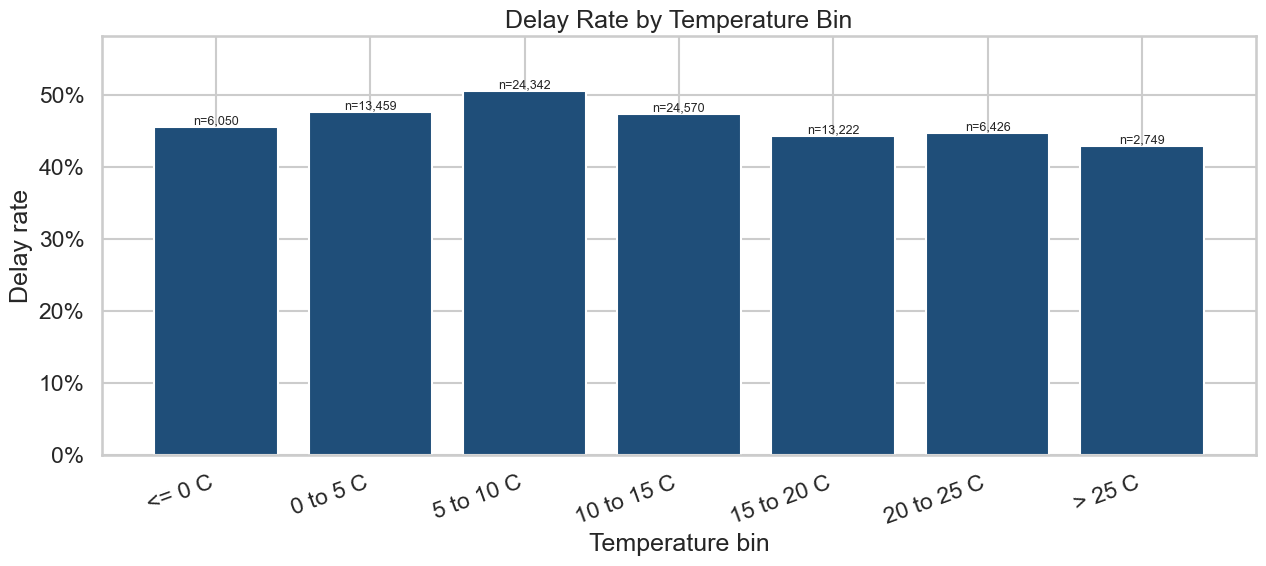

,precipitation_condition,rows,delay_rate,mean_delay_minutes,category
0,Dry hour,71664,0.456491,0.307718,Dry hour
1,Rainy hour,19154,0.540044,0.568103,Rainy hour


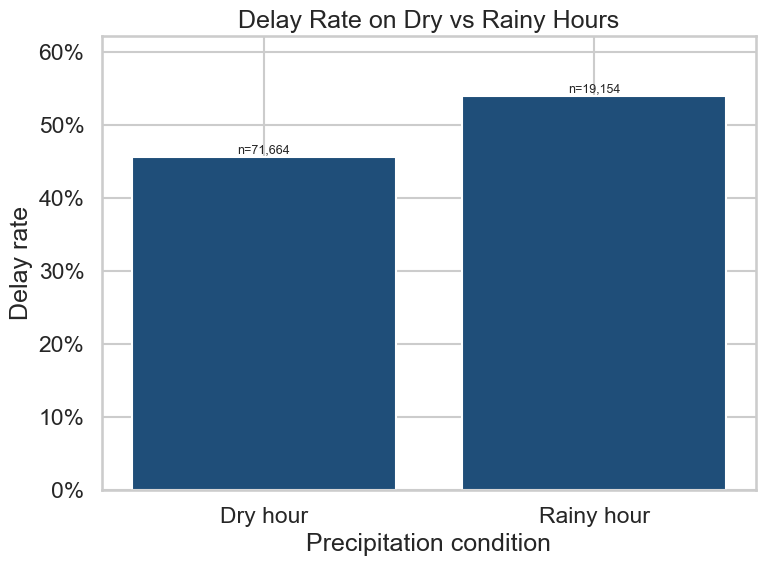

,snowfall_condition,rows,delay_rate,mean_delay_minutes,category
0,No snow,90092,0.473660,0.361051,No snow
1,Snowy hour,726,0.530303,0.559137,Snowy hour


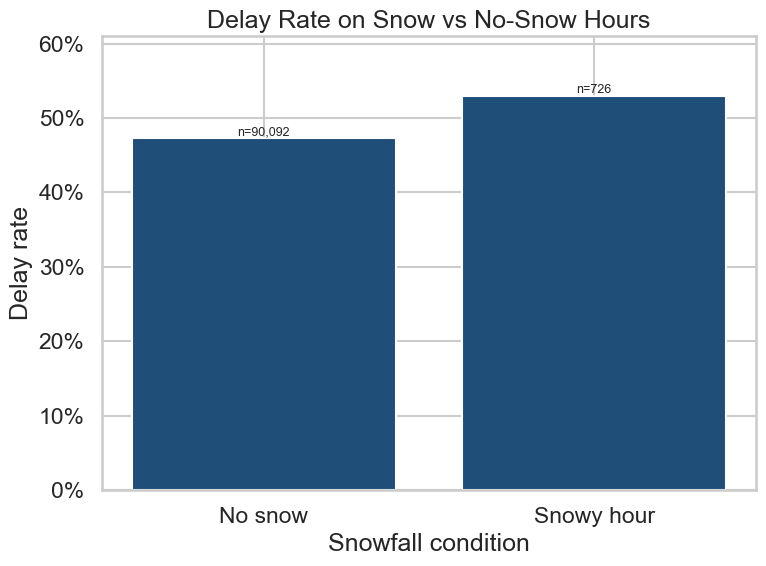

,wind_speed_bin,rows,delay_rate,mean_delay_minutes,category
0,0 to 5 km/h,18051,0.490555,0.401207,0 to 5 km/h
1,5 to 10 km/h,26029,0.467286,0.316598,5 to 10 km/h
2,10 to 15 km/h,23117,0.460181,0.375106,10 to 15 km/h
3,15 to 20 km/h,12475,0.472786,0.372754,15 to 20 km/h
4,20 to 25 km/h,4899,0.477648,0.333629,20 to 25 km/h
5,> 25 km/h,6247,0.506483,0.399392,> 25 km/h


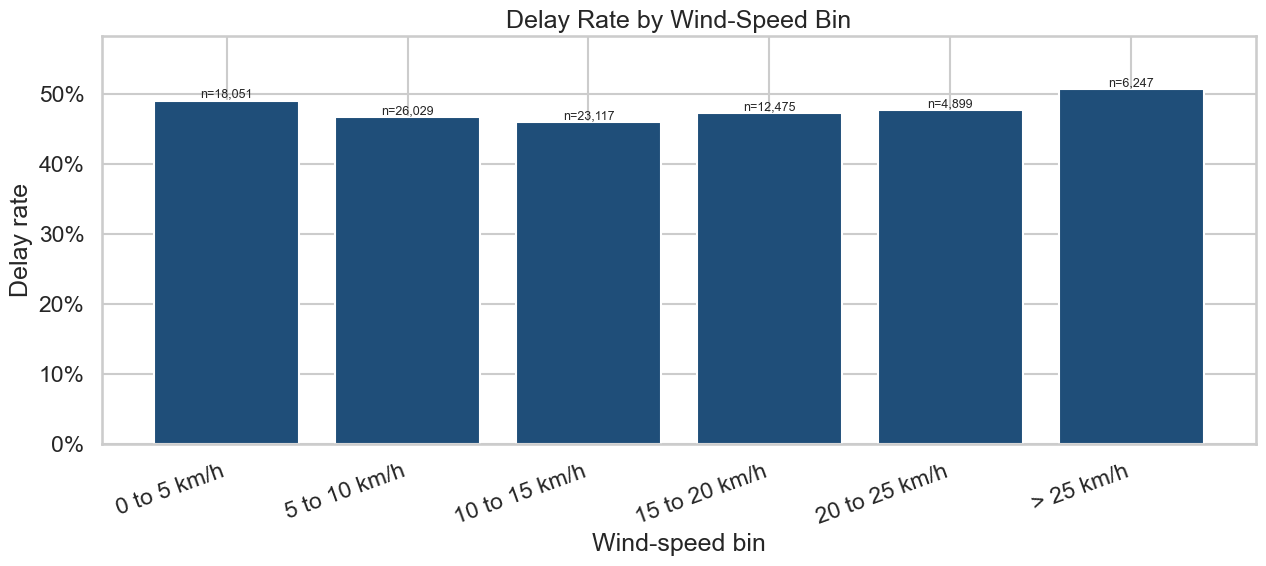

Saved weather-condition figures:
- outputs/figures/eda_12_delay_rate_by_temperature_bin.png
- outputs/figures/eda_13_delay_rate_dry_vs_rainy.png
- outputs/figures/eda_14_delay_rate_snow_vs_no_snow.png
- outputs/figures/eda_15_delay_rate_by_wind_speed_bin.png


In [15]:
weather_condition_summaries = {}
saved_weather_condition_plots = []

for spec in weather_delay_specs:
    summary = build_delay_summary(
        weather_delay_df,
        column=spec["column"],
        order=spec["order"],
    )
    weather_condition_summaries[spec["column"]] = summary
    display(summary)
    saved_weather_condition_plots.append(
        save_delay_rate_plot(
            summary,
            title=spec["title"],
            filename=spec["filename"],
            x_label=spec["x_label"],
            rotate=spec["rotate"],
            figsize=spec["figsize"],
            annotate_counts=True,
        )
    )

print("Saved weather-condition figures:")
for path in saved_weather_condition_plots:
    print(f"- {path.relative_to(ROOT)}")


## 2.8 Continuous weather relationships

This section keeps the weather variables continuous and asks whether the delay rate moves gradually with rain, wind, snowfall, or temperature rather than only by category.

**Files produced in next step:** `outputs/figures/eda_16_hourly_weather_vs_delay_rate.png`

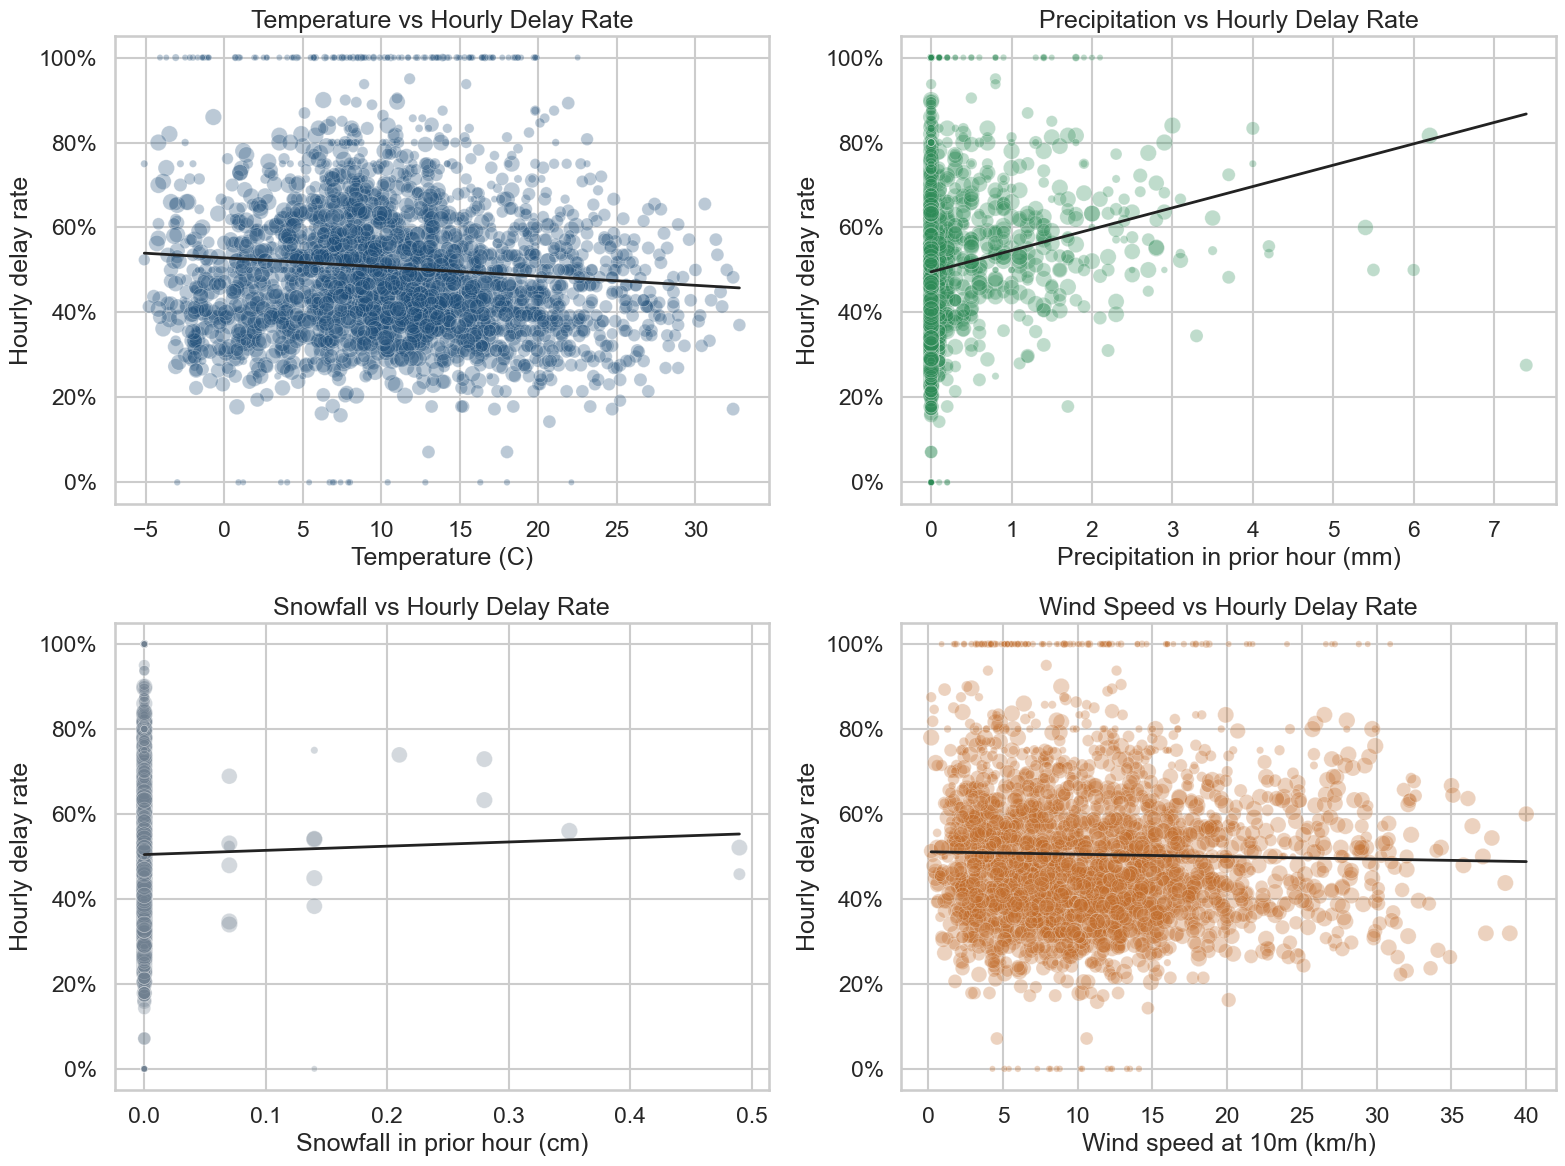

,delay_rate,mean_delay_minutes
delay_rate,1.000000,0.451001
mean_delay_minutes,0.451001,1.000000
temperature_2m,-0.088565,0.020969
precipitation,0.158095,0.020270
snowfall,0.010367,0.008327
wind_speed_10m,-0.023206,-0.032709
arrival_records,-0.386195,-0.222139


Saved figure to outputs/figures/eda_16_hourly_weather_vs_delay_rate.png


In [16]:
# These are continuous weather variables, so this section uses scatter/regression views rather than the earlier categorical bar plot helper.
weather_relationship_specs = [
    {
        "column": "temperature_2m",
        "title": "Temperature vs Hourly Delay Rate",
        "xlabel": "Temperature (C)",
        "color": "#1f4e79",
    },
    {
        "column": "precipitation",
        "title": "Precipitation vs Hourly Delay Rate",
        "xlabel": "Precipitation in prior hour (mm)",
        "color": "#2e8b57",
    },
    {
        "column": "snowfall",
        "title": "Snowfall vs Hourly Delay Rate",
        "xlabel": "Snowfall in prior hour (cm)",
        "color": "#708090",
    },
    {
        "column": "wind_speed_10m",
        "title": "Wind Speed vs Hourly Delay Rate",
        "xlabel": "Wind speed at 10m (km/h)",
        "color": "#c26d2c",
    },
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, spec in zip(axes.flat, weather_relationship_specs):
    sns.scatterplot(
        data=weather_hourly,
        x=spec["column"],
        y="delay_rate",
        size="arrival_records",
        sizes=(20, 140),
        alpha=0.30,
        color=spec["color"],
        legend=False,
        ax=ax,
    )
    sns.regplot(
        data=weather_hourly,
        x=spec["column"],
        y="delay_rate",
        scatter=False,
        ci=None,
        color="#222222",
        line_kws={"linewidth": 2},
        ax=ax,
    )
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_title(spec["title"])
    ax.set_xlabel(spec["xlabel"])
    ax.set_ylabel("Hourly delay rate")

fig.tight_layout()
weather_relationship_path = FIGURES_DIR / "eda_16_hourly_weather_vs_delay_rate.png"
fig.savefig(weather_relationship_path, dpi=200, bbox_inches="tight")
plt.show()

hourly_weather_relationship_summary = (
    weather_hourly[
        [
            "delay_rate",
            "mean_delay_minutes",
            "temperature_2m",
            "precipitation",
            "snowfall",
            "wind_speed_10m",
            "arrival_records",
        ]
    ]
    .corr(numeric_only=True)
    [["delay_rate", "mean_delay_minutes"]]
)

display(hourly_weather_relationship_summary)
print(f"Saved figure to {weather_relationship_path.relative_to(ROOT)}")


## 2.9 Multivariate interaction views

This section adds a few compact multivariate views so I can see whether the patterns from the earlier plots still hold when two dimensions are shown together.

**Files produced in next step:** `outputs/figures/eda_17_numeric_correlation_heatmap.png`, `outputs/figures/eda_18_hour_weekday_delay_heatmap.png`, and `outputs/figures/eda_19_rain_effect_by_hour_and_line.png`

,delay_minutes,delayed,scheduled_arrival_hour,scheduled_arrival_weekday,scheduled_arrival_month,temperature_2m,precipitation,snowfall,wind_speed_10m,is_weekend
delay_minutes,1.000,0.421,-0.021,-0.040,0.023,-0.004,0.038,0.009,0.002,-0.046
delayed,0.421,1.000,-0.045,-0.056,0.016,-0.025,0.063,0.012,0.004,-0.064
scheduled_arrival_hour,-0.021,-0.045,1.000,-0.010,-0.002,0.158,-0.022,-0.034,0.078,-0.014
scheduled_arrival_weekday,-0.040,-0.056,-0.010,1.000,0.002,0.006,-0.092,0.030,-0.050,0.779
scheduled_arrival_month,0.023,0.016,-0.002,0.002,1.000,0.491,0.059,-0.091,0.088,-0.003
temperature_2m,-0.004,-0.025,0.158,0.006,0.491,1.000,-0.037,-0.095,-0.126,0.010
precipitation,0.038,0.063,-0.022,-0.092,0.059,-0.037,1.000,0.054,0.128,-0.042
snowfall,0.009,0.012,-0.034,0.030,-0.091,-0.095,0.054,1.000,-0.002,-0.043
wind_speed_10m,0.002,0.004,0.078,-0.050,0.088,-0.126,0.128,-0.002,1.000,-0.022
is_weekend,-0.046,-0.064,-0.014,0.779,-0.003,0.010,-0.042,-0.043,-0.022,1.000


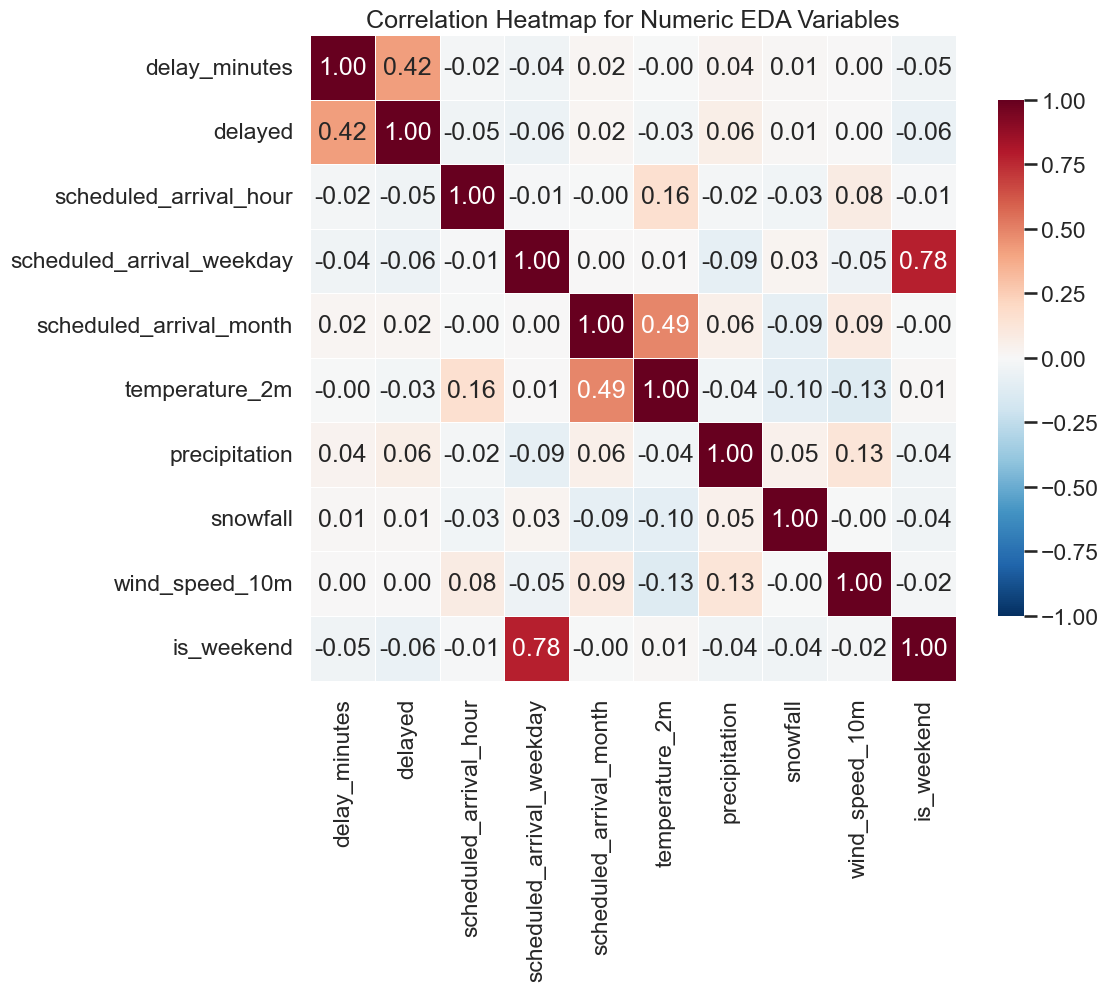

Saved figure to outputs/figures/eda_17_numeric_correlation_heatmap.png


In [17]:
# Restrict the correlation view to numeric analysis variables that speak directly to timing, weather, and the delay target.
numeric_eda_df = df[
    [
        "delay_minutes",
        "delayed",
        "scheduled_arrival_hour",
        "scheduled_arrival_weekday",
        "scheduled_arrival_month",
        "temperature_2m",
        "precipitation",
        "snowfall",
        "wind_speed_10m",
    ]
].copy()
numeric_eda_df["is_weekend"] = df["is_weekend"].astype(int)

correlation_matrix = numeric_eda_df.corr(numeric_only=True)
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_title("Correlation Heatmap for Numeric EDA Variables")
fig.tight_layout()

correlation_path = FIGURES_DIR / "eda_17_numeric_correlation_heatmap.png"
fig.savefig(correlation_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {correlation_path.relative_to(ROOT)}")


scheduled_arrival_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
scheduled_arrival_weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,0.608,0.651,0.583,1.000,0.923,0.616,0.578,0.673,0.648,0.519,...,0.425,0.516,0.492,0.539,0.504,0.475,0.451,0.482,0.460,0.585
Tuesday,0.652,0.699,1.000,1.000,0.700,0.631,0.546,0.602,0.550,0.477,...,0.413,0.464,0.469,0.529,0.496,0.484,0.427,0.462,0.516,0.592
Wednesday,0.658,0.714,0.750,1.000,0.735,0.644,0.571,0.618,0.578,0.443,...,0.392,0.421,0.465,0.506,0.493,0.457,0.435,0.458,0.538,0.620
Thursday,0.646,0.731,0.727,1.000,0.700,0.671,0.553,0.648,0.573,0.456,...,0.441,0.438,0.544,0.549,0.537,0.484,0.428,0.489,0.504,0.599
Friday,0.680,0.724,0.615,0.818,0.704,0.587,0.540,0.537,0.517,0.455,...,0.390,0.459,0.492,0.513,0.490,0.464,0.416,0.476,0.501,0.535
Saturday,0.516,0.606,0.496,0.731,0.364,0.587,0.514,0.402,0.382,0.365,...,0.415,0.404,0.391,0.406,0.445,0.448,0.439,0.446,0.478,0.477
Sunday,0.592,0.586,0.525,0.812,0.576,0.510,0.471,0.395,0.354,0.344,...,0.359,0.366,0.411,0.391,0.419,0.418,0.432,0.414,0.473,0.555


scheduled_arrival_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
scheduled_arrival_weekday_name,,,,,,,,,,,,,,,,,,,,,
Monday,291,106,12,5,26,302,670,697,702,665,...,671,675,677,684,674,672,687,521,457,426
Tuesday,299,73,3,2,30,344,744,788,786,750,...,760,761,761,766,766,752,775,585,514,476
Wednesday,339,91,8,5,34,388,832,883,873,838,...,849,853,853,852,837,818,832,636,572,516
Thursday,364,104,11,4,30,346,752,789,794,756,...,758,772,770,771,773,770,785,593,524,489
Friday,344,98,13,11,27,310,659,694,696,659,...,670,676,675,684,678,675,692,572,529,492
Saturday,318,251,117,67,33,259,553,605,671,666,...,667,676,673,655,678,665,676,554,519,478
Sunday,316,210,118,48,33,257,539,542,548,547,...,551,560,550,542,558,545,565,512,444,420


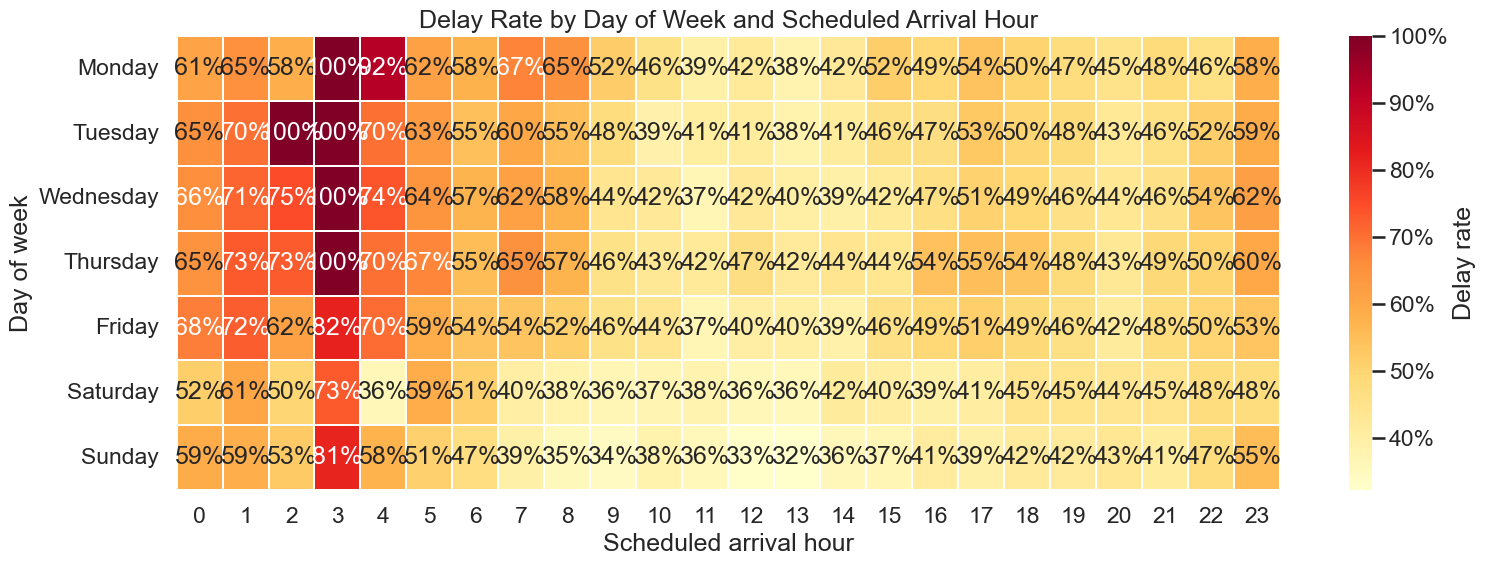

Saved figure to outputs/figures/eda_18_hour_weekday_delay_heatmap.png


In [18]:
hour_weekday_delay = (
    df.pivot_table(
        index="scheduled_arrival_weekday_name",
        columns="scheduled_arrival_hour",
        values="delayed",
        # mean turns the binary delayed flag into a delay rate for each cell for each weekday and hour.
        aggfunc="mean",
    )
    .reindex(weekday_order)
)

hour_weekday_counts = (
    df.pivot_table(
        index="scheduled_arrival_weekday_name",
        columns="scheduled_arrival_hour",
        values="delayed",
        # size preserves sample sizes so the heatmap can be interpreted alongside cell coverage.
        aggfunc="size",
    )
    .reindex(weekday_order)
    .fillna(0)
    .astype(int)
)

display(hour_weekday_delay.round(3))
display(hour_weekday_counts)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    hour_weekday_delay,
    cmap="YlOrRd",
    annot=True,
    # Annotations in percent format make the delay rate cells readable without an extra manual conversion step.
    fmt=".0%",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Delay rate"},
    ax=ax,
)
colorbar = ax.collections[0].colorbar
colorbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Delay Rate by Day of Week and Scheduled Arrival Hour")
ax.set_xlabel("Scheduled arrival hour")
ax.set_ylabel("Day of week")
fig.tight_layout()

hour_weekday_path = FIGURES_DIR / "eda_18_hour_weekday_delay_heatmap.png"
fig.savefig(hour_weekday_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved figure to {hour_weekday_path.relative_to(ROOT)}")


In [19]:
interaction_df = df.copy()
interaction_df["rain_condition"] = pd.Categorical(
    interaction_df["precipitation"].gt(0).map({False: "Dry hour", True: "Rainy hour"}),
    categories=["Dry hour", "Rainy hour"],
    ordered=True,
)


def build_rain_gap_table(
    data: pd.DataFrame,
    group_column: str,
    min_dry_rows: int,
    min_rainy_rows: int,
) -> pd.DataFrame:
    summary = (
        data.groupby([group_column, "rain_condition"], observed=False)
        .agg(rows=("delayed", "size"), delay_rate=("delayed", "mean"))
        .reset_index()
    )
    rates = summary.pivot(index=group_column, columns="rain_condition", values="delay_rate")
    counts = summary.pivot(index=group_column, columns="rain_condition", values="rows")
    effect = pd.DataFrame(
        {
            group_column: rates.index,
            "dry_delay_rate": rates["Dry hour"],
            "rainy_delay_rate": rates["Rainy hour"],
            "dry_rows": counts["Dry hour"],
            "rainy_rows": counts["Rainy hour"],
        }
    ).reset_index(drop=True)
    effect = effect[(effect["dry_rows"] >= min_dry_rows) & (effect["rainy_rows"] >= min_rainy_rows)].copy()
    effect["rain_delay_rate_gap"] = effect["rainy_delay_rate"] - effect["dry_delay_rate"]
    return effect


rain_hour_effect = build_rain_gap_table(
    interaction_df,
    group_column="scheduled_arrival_hour",
    min_dry_rows=150,
    min_rainy_rows=50,
)

display(rain_hour_effect.round(3))

rain_line_effect = build_rain_gap_table(
    interaction_df,
    group_column="line_name",
    min_dry_rows=500,
    min_rainy_rows=100,
)
rain_line_effect["total_rows"] = rain_line_effect["dry_rows"] + rain_line_effect["rainy_rows"]
# Keep only the busiest lines so the second panel stays legible and focuses on operationally important services.
rain_line_effect = rain_line_effect.sort_values("total_rows", ascending=False).head(12)

display(
    rain_line_effect[
        [
            "line_name",
            "dry_rows",
            "rainy_rows",
            "dry_delay_rate",
            "rainy_delay_rate",
            "rain_delay_rate_gap",
        ]
    ].round(3)
)

,scheduled_arrival_hour,dry_delay_rate,rainy_delay_rate,dry_rows,rainy_rows,rain_delay_rate_gap
0,0,0.608,0.678,1789,482,0.070
1,1,0.644,0.686,777,156,0.042
2,2,0.509,0.655,224,58,0.146
4,4,0.632,0.760,163,50,0.128
5,5,0.595,0.669,1699,507,0.074
6,6,0.523,0.603,3562,1187,0.080
7,7,0.540,0.640,3679,1319,0.100
8,8,0.494,0.602,3657,1413,0.108
9,9,0.420,0.496,3570,1311,0.076
10,10,0.397,0.472,3802,1115,0.075


,line_name,dry_rows,rainy_rows,dry_delay_rate,rainy_delay_rate,rain_delay_rate_gap
16,R20,21316,5560,0.460,0.511,0.051
22,RE33,6869,1840,0.617,0.704,0.088
17,R3,3779,1011,0.413,0.507,0.094
18,R4,3769,1021,0.454,0.588,0.133
20,R9,3724,1004,0.553,0.614,0.061
15,R2,3535,960,0.629,0.696,0.067
14,R1,3539,953,0.359,0.445,0.086
7,IC5,3402,891,0.315,0.444,0.129
9,IR15,3172,872,0.225,0.304,0.078
12,IR95,3144,847,0.263,0.357,0.094


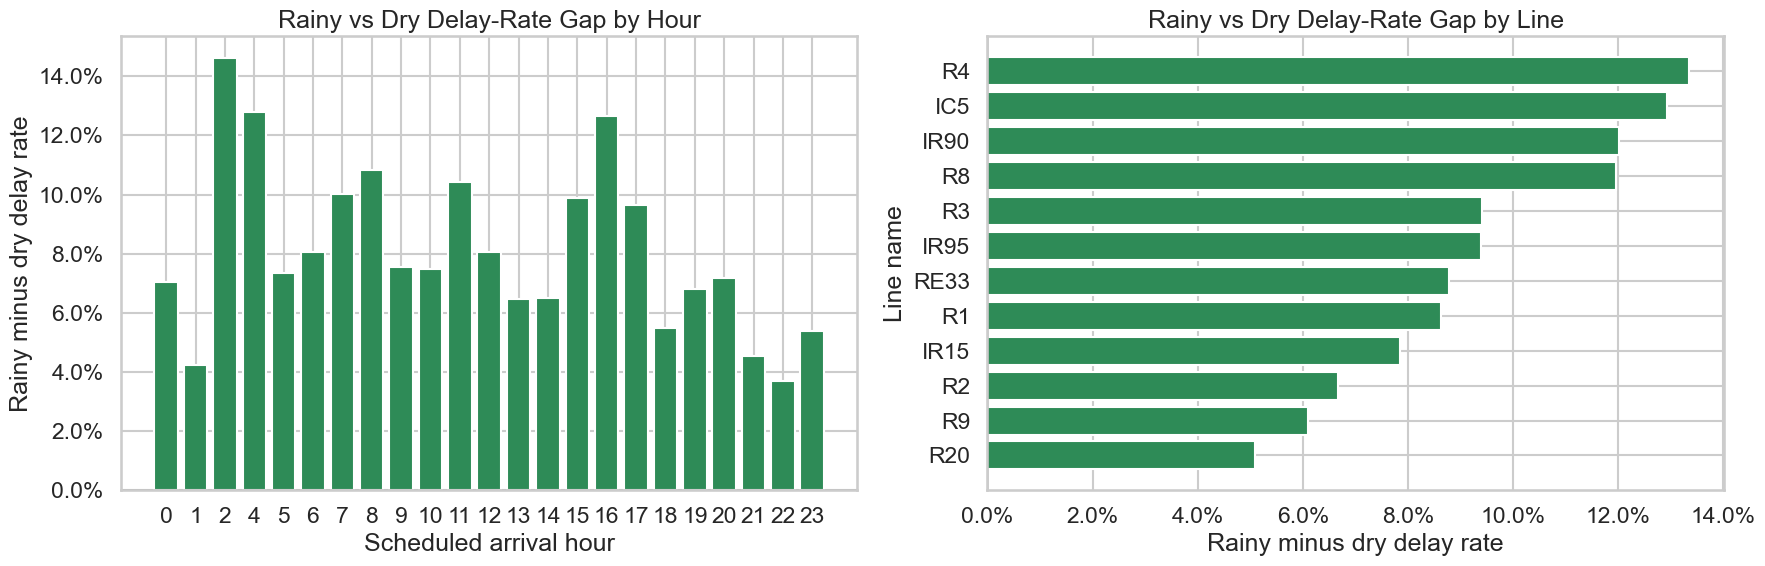

Hour-level comparison keeps hours with at least 150 dry rows and 50 rainy rows.
Line-level comparison keeps lines with at least 500 dry rows and 100 rainy rows.
Saved figure to outputs/figures/eda_19_rain_effect_by_hour_and_line.png


In [20]:
# Use a layout with two panels as a lightweight facet grid: hour on the left and the busiest lines on the right.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

hour_colors = rain_hour_effect["rain_delay_rate_gap"].apply(
    lambda value: "#2e8b57" if value >= 0 else "#b22222"
)
axes[0].bar(
    rain_hour_effect["scheduled_arrival_hour"].astype(str),
    rain_hour_effect["rain_delay_rate_gap"],
    color=hour_colors,
)
axes[0].axhline(0, color="#222222", linewidth=1)
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0].set_title("Rainy vs Dry Delay-Rate Gap by Hour")
axes[0].set_xlabel("Scheduled arrival hour")
axes[0].set_ylabel("Rainy minus dry delay rate")

line_effect_plot = rain_line_effect.sort_values("rain_delay_rate_gap")
line_colors = line_effect_plot["rain_delay_rate_gap"].apply(
    lambda value: "#2e8b57" if value >= 0 else "#b22222"
)
axes[1].barh(
    line_effect_plot["line_name"],
    line_effect_plot["rain_delay_rate_gap"],
    color=line_colors,
)
axes[1].axvline(0, color="#222222", linewidth=1)
axes[1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].set_title("Rainy vs Dry Delay-Rate Gap by Line")
axes[1].set_xlabel("Rainy minus dry delay rate")
axes[1].set_ylabel("Line name")

fig.tight_layout()
rain_interaction_path = FIGURES_DIR / "eda_19_rain_effect_by_hour_and_line.png"
fig.savefig(rain_interaction_path, dpi=200, bbox_inches="tight")
plt.show()

print("Hour-level comparison keeps hours with at least 150 dry rows and 50 rainy rows.")
print("Line-level comparison keeps lines with at least 500 dry rows and 100 rainy rows.")
print(f"Saved figure to {rain_interaction_path.relative_to(ROOT)}")

## 2.10 Key EDA Takeaways

This section summarizes the EDA:
- Delay rates shift clearly by scheduled arrival hour, weekday or weekend status, train type, and line.
- Rainy hours show higher delay rates than dry hours in both the hour level and line level interaction views.
- Snow looks weaker and less consistent than rain in the descriptive plots.
- Temperature and wind show some movement in hourly delay rates, but those patterns look more subtle than the main service and timing effects.
- These are the patterns I carry forward into the formal hypothesis tests.